In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [2]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 4
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [3]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)

In [4]:
from ctt.tt import tt_randn

key, *control_keys = random.split(key, 3+1)

target_ranks = [d_lift] + [2]*(d_lift-1) + [1]
target_tts = [
    tt_randn(control_key, [n_features] * d_lift, target_ranks, cov=3.0)
    for control_key in control_keys
]
target_ctt = make_ctt(lift, retraction, basis, d)

Sigma = random.normal(key=key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "bivariate"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "recovery":
        val = target_ctt(target_tts, x)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.mean((x[::2] + x[1::2]) ** 2)
    return jnp.atleast_1d(val)



In [5]:
from ctt.tt import validate_ranks

key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 1_000_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2
regularization_coeff = 0.
radius = None
rank = 3
ranks = [d_lift] + [rank]*(d_lift-1) + [1]
ranks = validate_ranks([n_features]*d_lift, ranks)

In [6]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [7]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"],
                 alpha: float = 0.) -> tuple[float,float]:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    # loss = jnp.mean(optax.l2_loss(y_pred, y))
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    # penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    penalty = 0.
    return loss + penalty, loss

In [8]:
import jax.flatten_util


@jax.jit
def get_gramian(params: list[TT], x: Float[Array, "B d"]) -> Float[Array, "n_params n_params"]:
    # f = lambda w: jax.vmap(ctt, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
    # J = jax.jacfwd(f)(params)
    # flatten_J, _ = jax.flatten_util.ravel_pytree(J)
    # flatten_J = jnp.reshape(flatten_J, (x.shape[0], -1))
    # G = flatten_J.T @ flatten_J
    # def _g(p, x):
    #     grads = jax.grad(lambda p,x: ctt(p, x)[0])(p, x)
    #     flatten_grads, _ = jax.flatten_util.ravel_pytree(grads)
    #     return flatten_grads
    
    # grads = jax.vmap(_g, in_axes=(None, 0))(params, x)
    # G = grads.T @ grads / x.shape[0]
    # return G
    flat_params, unravel_fn = jax.flatten_util.ravel_pytree(params)

    def _f(p):
        p = unravel_fn(p)
        return jax.vmap(ctt, in_axes=(None, 0))(p, x).ravel()
    
    J = jax.jacfwd(_f)(flat_params) # (n_output, n_params)
    G = J.T @ J / x.shape[0]
    return G

In [9]:
def sizeof_pytree(p) -> int:
    leaves = jax.tree.leaves(p)
    return sum(jnp.size(leaf) for leaf in leaves)

In [10]:
from ctt.tt import tt_orthogonalize

def left_orth(tt: TT) -> TT:
    U, V, S = tt_orthogonalize(tt)
    return [S[0]] + V

# Gradient Descent

In [11]:

def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     optimizer: optax.GradientTransformation,
                     params: list[TT],
                     opt_steps: int,
                     regularization_coeff: float,
                     training_key: PRNGKeyArray,
                     batch_size: int = 64,
                     backtraking: bool = False,
                     orthogonalize: bool = False) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        if backtraking:
            updates, opt_state = optimizer.update(grads, opt_state, tts, value=loss, grad=grads, value_fn=lambda p: compute_loss(p, x, y, alpha)[0])
        else:
            updates, opt_state = optimizer.update(grads, opt_state, tts) 
        params = optax.apply_updates(tts, updates)
        if orthogonalize:
            params = list(map(left_orth, params))
        return params, opt_state, l2_error

    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y,
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# Natural gradient descent

In [12]:
import jax.flatten_util
import operator
import lineax
from ctt.tt import tt_orthogonalize
from functools import partial

def natural_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             optimizer: optax.GradientTransformation,
                             params: list[TT],
                             opt_steps: int,
                             regularization_coeff: float,
                             training_key: PRNGKeyArray,
                             batch_size: int = 64,
                             backtracking: bool = False,
                             orthogonalize: bool = False) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    def tree_mvp_dampen(mvp, lmbda=0.1):
        dampen_fcn = lambda mvp_, v_: mvp_ + lmbda * v_
        damp_mvp = lambda v: jax.tree.map(dampen_fcn, mvp(v), v)
        return damp_mvp

    def _natural_grad(tts: list[TT], x: Float[Array, "B d"], grads: list[TT]) -> list[TT]:
        # f = lambda w: jax.vmap(ctt, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
        # fvp = lambda v: jax.vjp(f, tts)[1](jax.jvp(f, (tts,), (v,))[1])[0]
        # fvp = tree_mvp_dampen(fvp, lmbda=1e-4)
        # # ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grads, maxiter=40, tol=1e-10)
        # op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grads), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
        # solution = lineax.linear_solve(op, grads, solver=lineax.AutoLinearSolver(well_posed=True))
        # ngrad = solution.value
        # # r = jax.tree.map(operator.sub, grads, fvp(ngrad))
        # # r_norm = sum(jax.tree.leaves(jax.tree.map(jnp.vdot, r, r)))
        # # jax.debug.print("Residual: {r}", r=jnp.sqrt(r_norm))
        # return ngrad
        def _block_projection(grad: TT, k: int) -> TT:
            tt = tts[k]
            def _f(w: TT, *args: None) -> Float[Array, "N"]:
                params = tts[:k] + [w] + tts[k+1:]
                return jax.vmap(ctt, in_axes=(None, 0))(params, x).ravel() / jnp.sqrt(x.shape[0])
            fvp = lambda v: jax.vjp(_f, tt)[1](jax.jvp(_f, (tt,), (v,))[1])[0]
            fvp = tree_mvp_dampen(fvp, lmbda=1e-4)
            # ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grad, maxiter=40, tol=1e-10)
            op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grad), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
            solution = lineax.linear_solve(op, grad, solver=lineax.AutoLinearSolver(well_posed=True))
            ngrad = solution.value
            return ngrad
        
        ngrads = [_block_projection(grads[k], k) for k in range(len(tts))]
        return ngrads
        # flat_params, unravel = jax.flatten_util.ravel_pytree(tts)
        # def f(w):
        #     w = unravel(w)
        #     return jax.vmap(ctt, in_axes=(None, 0))(w, x).ravel()
        # J = jax.jacfwd(f)(flat_params)
        # G = J.T @ J / x.shape[0]
        # sigma, V = jnp.linalg.eigh(G)
        # jax.debug.print("Spectrum range: [{a}, {b}]", a=jnp.min(sigma), b=jnp.max(sigma))
        # indices = sigma > 1e-10
        # sigma_inv = jnp.where(indices, 1./sigma, 0)
        # V = jnp.where(indices, V, 0)

        # flat_grads, unravel = jax.flatten_util.ravel_pytree(grads)
        # ngrad = (V * sigma_inv) @ V.T @ flat_grads
        # ngrad = unravel(ngrad)
        # return ngrad

        # blocks = []
        # pos = 0
        # for i in range(len(tts)):
        #     size = sizeof_pytree(tts[i])
        #     block = G[pos:pos+size, pos:pos+size]
        #     pos += size
        #     blocks.append(block)
        
        # G_tilde = jax.scipy.linalg.block_diag(*blocks)
        # flat_grads, unravel = jax.flatten_util.ravel_pytree(grads)
        # ngrad, _ = jax.scipy.sparse.linalg.cg(G_tilde, flat_grads, maxiter=10)
        # ngrad = unravel(ngrad)
        # return ngrad

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        ngrad = _natural_grad(tts, x, grads)
        if backtracking:
            updates, opt_state = optimizer.update(ngrad, opt_state, tts, value=loss, grad=ngrad, value_fn=lambda p: compute_loss(p, x,y,alpha)[0])
        else:
            updates, opt_state = optimizer.update(ngrad, opt_state, tts)
        params = optax.apply_updates(tts, updates)
        if orthogonalize:
            params = list(map(left_orth, params))
        return params, opt_state, l2_error

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y,
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

# Comparison

In [13]:
from ctt.tt import tt_zeros, tt_randn

key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    tt_randn(control_key, [n_features] * d_lift, ranks, cov=1)
    for control_key in control_keys
]
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
# init_controls = list(map(left_orth, init_controls))
print(list(map(tt_norm, init_controls)))

[Array(0.00135499, dtype=float64), Array(0.00218429, dtype=float64)]


## Gradient descent

In [14]:
# optimizer = optax.adam(learning_rate=5e-3)
optimizer = optax.chain(
    optax.adam(learning_rate=1.),
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20)
)
# optimizer = optax.sgd(learning_rate=1e-1)
params_gd, (train_losses_gd, val_losses_gd) = gradient_descent(train_dataset=(X_train, y_train),
                                                               val_dataset=(X_val, y_val),
                                                               optimizer=optimizer,
                                                               params=init_controls,
                                                               opt_steps=40000,
                                                               regularization_coeff=regularization_coeff,
                                                               batch_size=128,
                                                               training_key=training_key,
                                                               backtraking=True,
                                                               orthogonalize=True)

Iter 0 | Loss: 4.403e-01 | Val loss: 5.616e-02
Iter 5 | Loss: 2.409e-02 | Val loss: 2.034e-02
Iter 10 | Loss: 1.183e-02 | Val loss: 1.370e-02
Iter 15 | Loss: 1.255e-02 | Val loss: 1.164e-02
Iter 20 | Loss: 9.587e-03 | Val loss: 1.056e-02
Iter 25 | Loss: 1.015e-02 | Val loss: 8.880e-03
Iter 30 | Loss: 7.782e-03 | Val loss: 8.120e-03
Iter 35 | Loss: 6.971e-03 | Val loss: 7.118e-03
Iter 40 | Loss: 8.359e-03 | Val loss: 6.647e-03
Iter 45 | Loss: 7.359e-03 | Val loss: 6.260e-03
Iter 50 | Loss: 4.936e-03 | Val loss: 5.736e-03
Iter 55 | Loss: 6.056e-03 | Val loss: 5.441e-03
Iter 60 | Loss: 4.754e-03 | Val loss: 5.330e-03
Iter 65 | Loss: 4.661e-03 | Val loss: 5.029e-03
Iter 70 | Loss: 4.535e-03 | Val loss: 4.677e-03
Iter 75 | Loss: 3.890e-03 | Val loss: 4.593e-03
Iter 80 | Loss: 3.887e-03 | Val loss: 4.068e-03
Iter 85 | Loss: 3.619e-03 | Val loss: 3.692e-03
Iter 90 | Loss: 3.302e-03 | Val loss: 3.441e-03
Iter 95 | Loss: 3.292e-03 | Val loss: 3.375e-03
Iter 100 | Loss: 4.257e-03 | Val loss: 3.3

## Natural gradient descent

In [ ]:
# optimizer = optax.adam(learning_rate=1e-3)
# optimizer = optax.sgd(learning_rate=5e-2)
optimizer = optax.chain(
    optax.sgd(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20, store_grad=True)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="one")
)
params_ngd, (train_losses_ngd, val_losses_ngd), learning_rates = natural_gradient_descent(train_dataset=(X_train, y_train),
                                                                       val_dataset=(X_val, y_val),
                                                                       optimizer=optimizer,
                                                                       params=init_controls,
                                                                       opt_steps=40000,
                                                                       regularization_coeff=regularization_coeff,
                                                                       batch_size=128,
                                                                       training_key=training_key,
                                                                       backtracking=True,
                                                                       orthogonalize=True)

Iter 0 | Loss: 3.436e-01 | Val loss: 1.219e-01
Iter 5 | Loss: 8.414e-03 | Val loss: 3.888e-03
Iter 10 | Loss: 5.211e-04 | Val loss: 4.141e-04
Iter 15 | Loss: 1.854e-04 | Val loss: 2.075e-04
Iter 20 | Loss: 1.395e-04 | Val loss: 9.962e-05
Iter 25 | Loss: 9.776e-05 | Val loss: 1.015e-04
Iter 30 | Loss: 6.206e-05 | Val loss: 6.237e-05
Iter 35 | Loss: 5.797e-05 | Val loss: 5.469e-05
Iter 40 | Loss: 5.302e-05 | Val loss: 4.529e-05
Iter 45 | Loss: 6.542e-05 | Val loss: 3.955e-05
Iter 50 | Loss: 4.432e-05 | Val loss: 4.260e-05
Iter 55 | Loss: 4.432e-05 | Val loss: 3.634e-05
Iter 60 | Loss: 4.077e-05 | Val loss: 4.582e-05
Iter 65 | Loss: 6.396e-05 | Val loss: 5.076e-05
Iter 70 | Loss: 5.557e-05 | Val loss: 5.465e-05
Iter 75 | Loss: 1.018e-04 | Val loss: 7.353e-05
Iter 80 | Loss: 4.683e-05 | Val loss: 5.187e-05
Iter 85 | Loss: 5.140e-05 | Val loss: 5.066e-05
Iter 90 | Loss: 2.862e-05 | Val loss: 3.132e-05
Iter 95 | Loss: 5.292e-05 | Val loss: 4.945e-05
Iter 100 | Loss: 2.244e-05 | Val loss: 2.8

KeyboardInterrupt: 

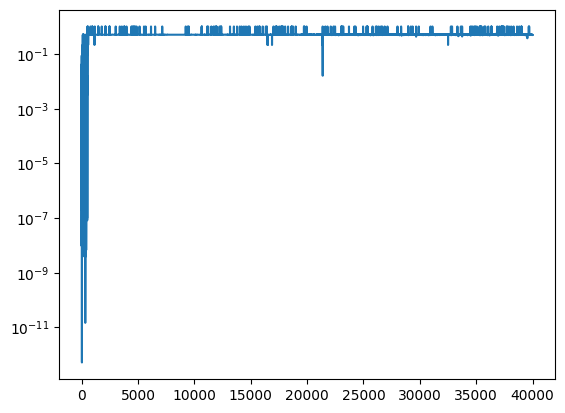

In [70]:
plt.semilogy(learning_rates)

## Plotting the errors

Text(0, 0.5, 'Error')

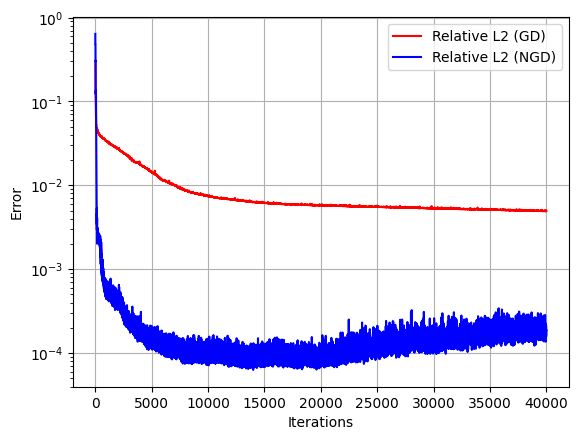

In [71]:
fig, ax = plt.subplots()

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot GD losses
val_losses_gd = jnp.asarray(val_losses_gd)

ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (GD)", color="red")

# plot NGD losses
val_losses_ngd = jnp.asarray(val_losses_ngd)

ax.semilogy(jnp.arange(len(val_losses_ngd)), jnp.sqrt(val_losses_ngd/y_val_norm), label="Relative L2 (NGD)", color="blue")

ax.grid()
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Error")

## Visualize Gramian

In [18]:
N_gram = 500_000
key, gram_key = random.split(key)
X_gram = random.uniform(key=gram_key, shape=(N_gram, d), minval=domain[0], maxval=domain[1])
# G = get_gramian(list(map(left_orth, params_ngd)), X_gram)
# G = get_gramian(params_ngd, X_gram)
G = get_gramian(init_controls, X_gram)

In [19]:
pos = 0
blocks = []
for i in range(num_steps):
    size = sizeof_pytree(init_controls[i])
    block = G[pos:pos+size, pos:pos+size]
    blocks.append(block)
    pos += size

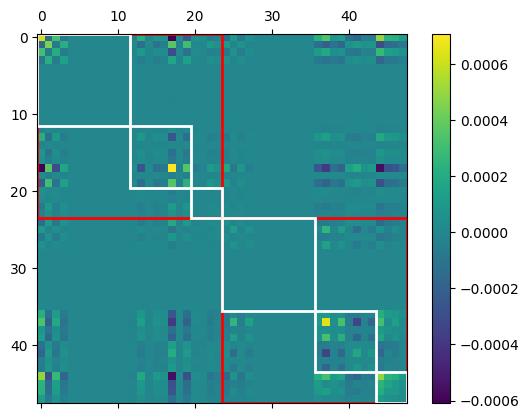

In [20]:
import matplotlib.patches as patches

fig, ax = plt.subplots()
# plot the Gram matrix
im = ax.matshow(G, cmap="viridis")
# draw the block diagonals
pos = 0
for i in range(num_steps):
    size = sizeof_pytree(init_controls[i])
    rect = patches.Rectangle((pos-0.5, pos-0.5), size, size, linewidth=2, edgecolor="r", facecolor='none')
    ax.add_patch(rect)
    inner_pos = pos
    for j in range(len(init_controls[i])):
        core_size = sizeof_pytree(init_controls[i][j])
        rect = patches.Rectangle((inner_pos-0.5, inner_pos-0.5), core_size, core_size, linewidth=2, edgecolor="white", facecolor="none")
        ax.add_patch(rect)
        inner_pos += core_size
    pos += size
ax.set_aspect("equal")
fig.colorbar(im, ax=ax)

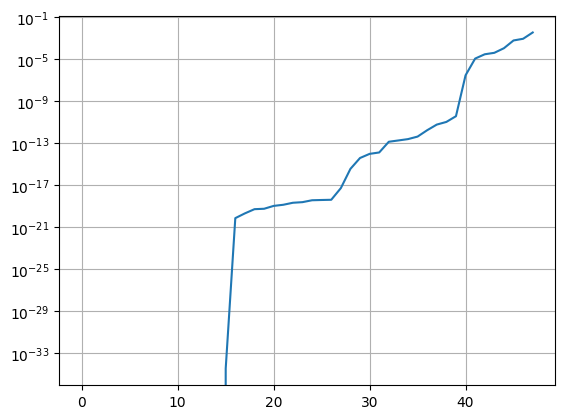

In [21]:
sigma, V = jnp.linalg.eigh(G)
plt.semilogy(sigma)
plt.grid()

In [26]:
indices = sigma > 1e-10
(V[:, indices] * sigma[indices]) @ V[:, indices].T - G

Array([[-1.56446362e-13,  8.79148642e-14, -3.71400881e-13, ...,
         1.57672215e-13, -3.03964319e-13, -1.62387288e-13],
       [ 8.79148913e-14, -3.34425684e-13,  4.37880987e-13, ...,
        -3.11028547e-13,  3.20854915e-13,  1.63785557e-13],
       [-3.71400881e-13,  4.37880973e-13, -1.17456056e-12, ...,
         6.17508919e-13, -8.82653081e-13, -4.59710307e-13],
       ...,
       [ 1.57672161e-13, -3.11028547e-13,  6.17508892e-13, ...,
        -4.02028210e-13,  4.56988166e-13,  2.33712721e-13],
       [-3.03964319e-13,  3.20854915e-13, -8.82653081e-13, ...,
         4.56988180e-13, -6.99235686e-13, -3.69679825e-13],
       [-1.62387302e-13,  1.63785557e-13, -4.59710313e-13, ...,
         2.33712734e-13, -3.69679832e-13, -1.96703710e-13]],      dtype=float64)